# NPS-LogP Quick Start Guide

This notebook demonstrates the basic usage of the LogP foundation model for:
- Crystal structure denoising
- Phase classification
- Order parameter computation

## Installation

If you haven't installed NPS yet:
```bash
pip install -e /path/to/NPS
```

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import ase
from ase import Atoms
from ase.build import bulk
from ase.io import write, read

# Import NPS-LogP modules
from NPS.logp import denoise_structure, classify_structure
from NPS.logp.models import LitLogPModel
from NPS.logp import STRUCTURE_TYPES, get_common_name

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

/opt/anaconda3/envs/nps-logp/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
PyTorch version: 2.9.1
CUDA available: False


## 1. Create Example Structures

Let's create some simple crystal structures to work with.

In [2]:
# Create BCC, FCC, and HCP iron structures
bcc_fe = bulk('Fe', 'bcc', a=2.87, cubic=True) * (5, 5, 5)
fcc_fe = bulk('Fe', 'fcc', a=3.59, cubic=True) * (4, 4, 4)
hcp_fe = bulk('Fe', 'hcp', a=2.52, c=4.11) * (5, 5, 3)

print(f"BCC Fe: {len(bcc_fe)} atoms")
print(f"FCC Fe: {len(fcc_fe)} atoms")
print(f"HCP Fe: {len(hcp_fe)} atoms")

BCC Fe: 250 atoms
FCC Fe: 256 atoms
HCP Fe: 150 atoms


In [3]:
# Add thermal noise to simulate MD snapshot
def add_noise(atoms, sigma=0.1):
    """Add Gaussian noise to atomic positions."""
    noisy = atoms.copy()
    noise = np.random.randn(*atoms.positions.shape) * sigma
    noisy.positions += noise
    return noisy

# Create noisy versions
noisy_bcc = add_noise(bcc_fe, sigma=0.15)
noisy_fcc = add_noise(fcc_fe, sigma=0.15)

print(f"Added noise with sigma=0.15 Å")

Added noise with sigma=0.15 Å


## 2. Load Pre-trained Model

Load your pre-trained LogP model checkpoint.

In [4]:
# Path to your checkpoint file
CHECKPOINT_PATH = "./checkpoint.ckpt" 

# Structure types (40 AFLOW prototypes)
print(f"Loaded {len(STRUCTURE_TYPES)} structure types")
print(f"First 5: {STRUCTURE_TYPES[:5]}")
print(f"Last 5: {STRUCTURE_TYPES[-5:]}")

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {device}")

Loaded 40 structure types
First 5: ['A_cP240_205', 'A_cI16_206', 'A_hP3_191', 'A_oF8_70', 'A_cP1_221']
Last 5: ['A_hP1_191', 'A_cP20_213', 'A_hP6_164', 'A_oC4_63', 'A_hP4_194']

Using device: cpu


In [5]:
# Load the model
print(f"Loading: {CHECKPOINT_PATH}")

lit_model = LitLogPModel.load_from_checkpoint(
    CHECKPOINT_PATH,
    map_location=device
)

# Get EMA-averaged model for inference
model = lit_model.get_inference_model()
model = model.to(device)
model.eval()

print(f"✓ Model loaded!")
print(f"  - Structure types: {len(STRUCTURE_TYPES)} classes")
print(f"  - Device: {device}")

Loading: ./checkpoint.ckpt


/opt/anaconda3/envs/nps-logp/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
/opt/anaconda3/envs/nps-logp/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/opt/anaconda3/envs/nps-logp/lib/python3.11/site-packages/mace/modules/blocks.py:312: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(atomic_energies, dtype=torch.get_default_dtype()),
/opt/anaconda3/envs/nps-logp/lib/python3.11/site-packa

✓ Model loaded!
  - Structure types: 40 classes
  - Device: cpu


## 3. Denoise a Structure

Remove thermal noise from atomic positions using gradient ascent in log-probability space.

In [7]:
# Denoise the noisy BCC structure
denoised_bcc, trajectory = denoise_structure(
    noisy_bcc,
    model=model,
    steps=8,
    cutoff=6.0,
    sigma_scale=1.0,
    device=device,
    return_trajectory=True,
)

print(f"Denoising complete! Trajectory has {len(trajectory)} frames.")

Denoising complete! Trajectory has 9 frames.


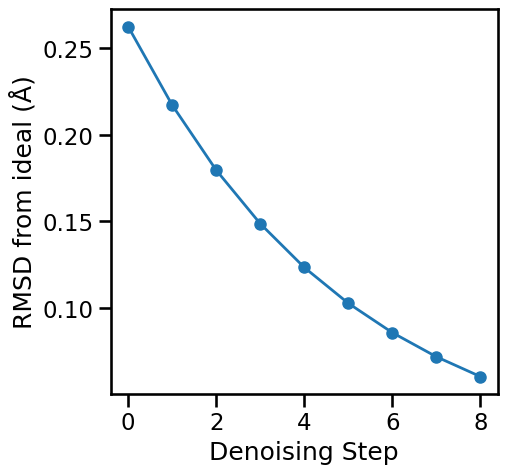

Initial RMSD: 0.2624 Å
Final RMSD: 0.0602 Å


In [9]:
# Plot RMSD evolution during denoising
def compute_rmsd(pos1, pos2):
    """Compute RMSD between two position arrays."""
    diff = pos1 - pos2
    return np.sqrt(np.mean(np.sum(diff**2, axis=1)))

# RMSD relative to ideal structure
rmsd_values = [compute_rmsd(frame.positions, bcc_fe.positions) for frame in trajectory]
import seaborn as sns;sns.set_context('talk')
plt.figure(figsize=(5, 5))
plt.plot(rmsd_values, 'o-', linewidth=2, markersize=8)
plt.xlabel('Denoising Step')
plt.ylabel('RMSD from ideal (Å)')
plt.show()

print(f"Initial RMSD: {rmsd_values[0]:.4f} Å")
print(f"Final RMSD: {rmsd_values[-1]:.4f} Å")

## 4. Classify Crystal Structure

Assign phase labels to each atom based on log-probabilities.

In [11]:
# Classify the noisy BCC structure
result = classify_structure(
    noisy_bcc,
    model=model,
    structure_types=STRUCTURE_TYPES,
    steps=8,
    cutoff=6.0,
    device=device,
)

# Get the predicted class
predicted_aflow = result['majority_class']
common_name = get_common_name(predicted_aflow)

print(f"Classification Results:")
print(f"  Predicted: {predicted_aflow} ({common_name})")
print(f"  Confidence: {result['confidence']:.4f}")

Classification Results:
  Predicted: A_cI2_229 (bcc)
  Confidence: 12.2801


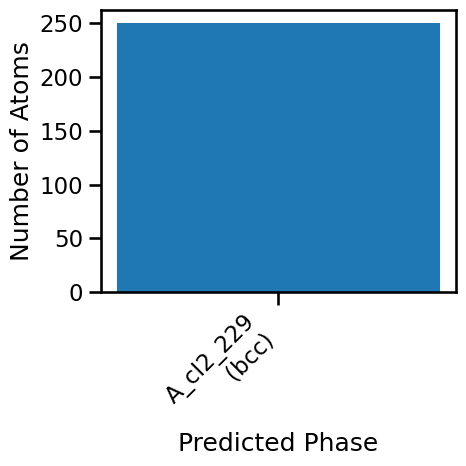

In [13]:
# Show distribution of predictions
predictions = result['predictions']
unique, counts = np.unique(predictions, return_counts=True)

# Get top 5 predictions
sorted_idx = np.argsort(counts)[::-1][:5]

plt.figure(figsize=(5, 5))
labels = [f"{STRUCTURE_TYPES[unique[i]]}\n({get_common_name(STRUCTURE_TYPES[unique[i]])})" 
          for i in sorted_idx]
plt.bar(labels, counts[sorted_idx])
plt.xlabel('Predicted Phase')
plt.ylabel('Number of Atoms')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Compute Order Parameters

The log-probability values serve as continuous order parameters for each phase.

In [17]:
from NPS.logp.inference import compute_order_parameters

# Compute order parameters
ops = compute_order_parameters(
    noisy_bcc,
    model=model,
    structure_types=STRUCTURE_TYPES,
    steps=8,
    cutoff=6.0,
    device=device,
)

# Print summary for common phases
print("Order Parameter Summary (common phases):")
for aflow_name in ["A_cI2_229", "A_cF4_225", "A_hP2_194"]:  # BCC, FCC, HCP
    if aflow_name in ops:
        values = ops[aflow_name]
        common = get_common_name(aflow_name)
        print(f"  {common} ({aflow_name}): mean={np.mean(values):.4f}, std={np.std(values):.4f}")

Order Parameter Summary (common phases):
  bcc (A_cI2_229): mean=12.2801, std=0.1340
  fcc (A_cF4_225): mean=0.9362, std=0.2959
  hcp (A_hP2_194): mean=-0.3004, std=0.1771


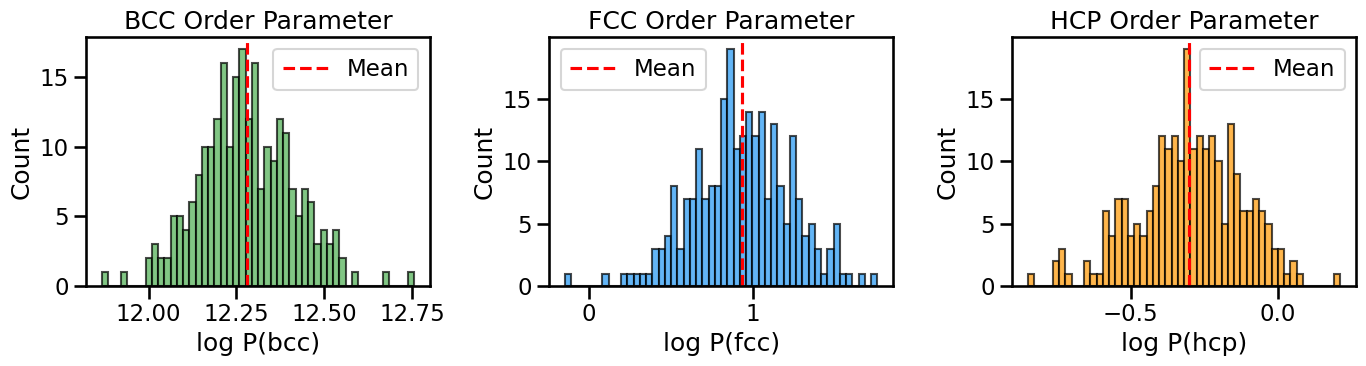

In [18]:
# Plot order parameter distributions for BCC, FCC, HCP
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

phase_names = ["A_cI2_229", "A_cF4_225", "A_hP2_194"]  # BCC, FCC, HCP
colors = ['#4CAF50', '#2196F3', '#FF9800']

for ax, aflow_name, color in zip(axes, phase_names, colors):
    if aflow_name in ops:
        common = get_common_name(aflow_name)
        ax.hist(ops[aflow_name], bins=50, color=color, alpha=0.7, edgecolor='black')
        ax.set_xlabel(f'log P({common})')
        ax.set_ylabel('Count')
        ax.set_title(f'{common.upper()} Order Parameter')
        ax.axvline(np.mean(ops[aflow_name]), color='red', linestyle='--', label='Mean')
        ax.legend()

plt.tight_layout()
plt.show()

## 6. Compare Multiple Structures

In [19]:
# Classify multiple structures
structures = {
    'BCC (noisy)': noisy_bcc,
    'FCC (noisy)': noisy_fcc,
    'BCC (ideal)': bcc_fe,
}

print("Classification comparison:")
print("-" * 60)

for name, atoms in structures.items():
    result = classify_structure(
        atoms, model, STRUCTURE_TYPES,
        steps=8, cutoff=6.0, device=device
    )
    predicted = result['majority_class']
    common = get_common_name(predicted)
    print(f"{name:20s} -> {common:8s} ({predicted}) | confidence: {result['confidence']:.4f}")

Classification comparison:
------------------------------------------------------------
BCC (noisy)          -> bcc      (A_cI2_229) | confidence: 12.2801
FCC (noisy)          -> fcc      (A_cF4_225) | confidence: 15.3243
BCC (ideal)          -> bcc      (A_cI2_229) | confidence: 12.3831


## 7. Save Results

In [20]:
# Save denoised structure
write('denoised_bcc.extxyz', denoised_bcc)
print("Saved denoised structure to denoised_bcc.extxyz")

# Save denoising trajectory
write('denoising_trajectory.extxyz', trajectory)
print("Saved trajectory to denoising_trajectory.extxyz")

Saved denoised structure to denoised_bcc.extxyz
Saved trajectory to denoising_trajectory.extxyz


## AFLOW Prototype Reference

Common structure type mappings:

| AFLOW Prototype | Common Name |
|-----------------|-------------|
| A_cI2_229 | BCC |
| A_cF4_225 | FCC |
| A_hP2_194 | HCP |
| A_hP4_194 | DHCP |
| A_cP1_221 | Simple Cubic |
| A_tI2_139 | BCT |
| A_hR1_166 | Omega |
| A_cF8_227 | Diamond |

## Next Steps

- See `02_training_custom_model.ipynb` to train your own model
- See `03_analyzing_md_trajectories.ipynb` for analyzing MD simulations